<a href="https://colab.research.google.com/github/Feznix/Stats-554/blob/Homework-5/Homework6_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Heather Secrest

Date: 05/12/2026

Course: ST 554 (601)

# **Homework 6**

#**Example Code**

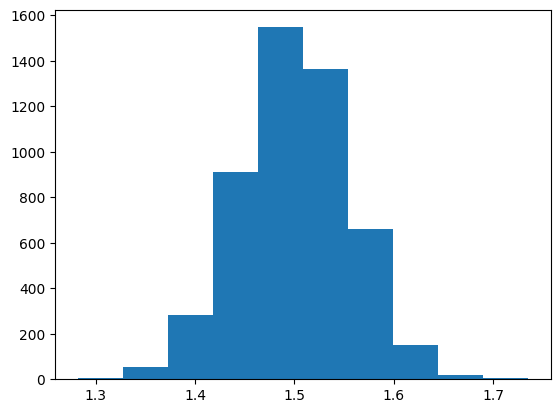

np.float64(0.0038)

In [8]:
#import some modules needed
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import default_rng
from sklearn import linear_model
rng = default_rng(32)
beta_0 = 7
beta_1 = 1.5
# get three 'values' of x at each integer from 0 to 10.
x = list(np.linspace(start = 0, stop = 10, num = 11))*3
n = len(x)
#prepare for the LR fit
reg = linear_model.LinearRegression()
#Create a reg object
#initialize array to save estimates (we don't need beta0 but I'm keeping it!)
beta_array = np.zeros(shape = (5000, 2))
for i in range(5000):
#create the 'responses' modeled from the line plus a random deviation
  y = beta_0 + beta_1*np.array(x) + rng.standard_normal(n)
#find the least squares solutions and store them
  fit = reg.fit(np.array(x).reshape(-1,1), y)
  beta_array[i, :] = [fit.intercept_, fit.coef_[0]]
#visualize the distribution of the slopedata
plt.hist(beta_array[:, 1])
plt.show()
#estimate the probability we are larger than 1.65
bool_prob = beta_array[:, 1] > 1.65
bool_prob.mean()


#**Class Code**

Here is my class code.
I started from the beginning and defined all of the things I needed, then did the different methods one by one following the guide in the homework.

I couldn't figure out how to make x input as an array so instead I changed it into an array where it needed to be one. I also couldn't figure out how to define it within the intital line without it being an empty list instead so I put the default value of x above.

I I decided that sigma was probably the test value used in the last method to find the probability so I used it as that since I couldn't find it in the code above.

I mostly had to edit for syntax errors and I tried to cut down redundant code where I could.

In [83]:
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import default_rng
from sklearn import linear_model

class SLR_slope_simulator:
  #set up my linear model to shortcut as reg

  z=list(np.linspace(start = 0, stop = 10, num = 11))*3
# my __init__ statement. I added initial default variables for
# beat_0, beata_1, and sigma. I did not default the seed because that seems weird
#I also did not default the x so you can input a list of your own x values
#I did however provide an x list from 1-10 following the code above later
#I also decided I needed to set up n and y
#I also added an empty slope list that can be filled later with run_simulations
  def __init__(self, beta_0=7.0, beta_1=1.5, x = list(np.linspace(start = 0, stop = 10, num = 11))*3, sigma=1.65, seed=32):
    self.beta_0 = beta_0
    self.beta_1= beta_1
    self.x = x
    self.sigma = sigma
    self.seed = seed
    self.slope = []
    self.rng = default_rng(self.seed)



#I provided an x list from 1-10 following the code above later
#I basically did this according to the above code
  def generate_data(self):
    self.n = len(self.x)
    self.y= self.beta_0 + self.beta_1*np.array(self.x) + self.rng.standard_normal(self.n)

#For this I just used the reg.fit of x, y to generate my slope of best fit
#I didn't add print functions to either this or the above to avoid cluttering my run_simulations
  def fit_slope(self):
    self.reg = linear_model.LinearRegression()
    self.fit = self.reg.fit(np.array(self.x).reshape(-1, 1), self.y)

#I did this basically like the homework said to
#Because the slopes is an empty list I used .append to add to it like my hw 5 code
  def run_simulations(self, simulations: int):
    self.simulations=simulations
    for i in range(simulations):
      self.generate_data()
      self.fit_slope()
      self.slope.append(self.fit.coef_.round(3))

  #The if else statement controls if this runs or not
  #(aka. it only works if you have already run the above method)
  #I basically just took the plot from the above code
  def plot_sampling_distribution(self):
      if len(self.slope)>0:
        plt.hist(np.array(self.slope))
        plt.show()
      else:
        print('run_simulations must be called first')
#This is the most complicated.
#I wanted two distinct error codes depending on the situation so
# I added nested if else statements.
#The outside one runs a test to see if run_simulation has been done;
#If it hasn't we print run_simulations must be called first.
#My next set does the different test types.
#Above runs if the sided argument is above and does the math.
#Below runs if the sided argument is below and does the math.
#Two-sided is nested again because we do different things if
#the sigma is above or below the median, but again does the math.
#I added an else here to tell the user what arguments were needed
#in case they didn't put in the proper one.
  def find_prob(self, sigma: float, sided: str):
    self.sigma=sigma
    if self.simulations > 0:
      if sided =='above':
        sum1= len([i for i in self.slope if i > self.sigma])
        prob= sum1/self.simulations
        print(prob)
      elif sided =='below':
        sum1= len([i for i in self.slope if i < self.sigma])
        prob= sum1/self.simulations
        print(prob)
      elif sided == 'two-sided':
        if self.sigma > np.median(np.array(self.slope)):
          sum1= len([i for i in self.slope if i > self.sigma])
          prob= (sum1/self.simulations)*2
          print(prob)
        elif self.sigma < np.median(np.array(self.slope)):
          sum1= len([i for i in self.slope if i < self.sigma])
          prob= sum1/self.simulations
          print(prob)
      else:
        print('Test type argument needed as "above", "below", or "two-sided"')
    else:
        print('run_simulations must be called first')


#**Test Code**

This is the code needed to test the class code written above.

In [84]:
SLR1 = SLR_slope_simulator(12,2,x,1,10)
SLR.plot_sampling_distribution()

run_simulations must be called first


In [85]:
SLR1.run_simulations(10000)

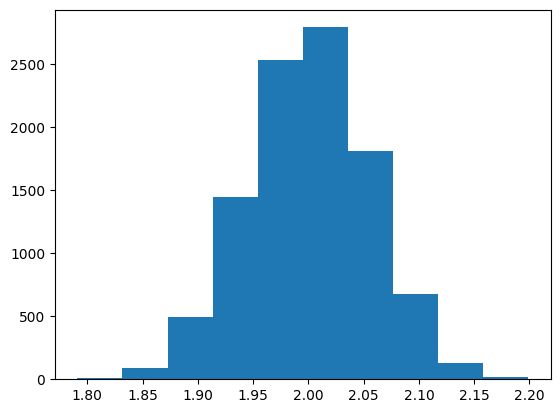

In [86]:
SLR1.plot_sampling_distribution()

In [87]:
SLR1.find_prob(2.1,'two-sided')

0.0696


In [78]:
SLR1.slope

[array([2.024]),
 array([1.996]),
 array([2.042]),
 array([1.965]),
 array([2.011]),
 array([1.986]),
 array([2.034]),
 array([2.09]),
 array([2.017]),
 array([1.912]),
 array([2.072]),
 array([2.008]),
 array([2.081]),
 array([2.047]),
 array([1.987]),
 array([2.104]),
 array([2.031]),
 array([1.919]),
 array([1.987]),
 array([1.959]),
 array([2.007]),
 array([2.097]),
 array([2.095]),
 array([1.945]),
 array([1.938]),
 array([2.019]),
 array([2.089]),
 array([2.072]),
 array([2.046]),
 array([2.055]),
 array([2.034]),
 array([2.028]),
 array([2.035]),
 array([2.053]),
 array([1.877]),
 array([2.026]),
 array([1.96]),
 array([2.021]),
 array([2.061]),
 array([2.124]),
 array([1.984]),
 array([1.979]),
 array([2.082]),
 array([1.98]),
 array([1.942]),
 array([2.011]),
 array([1.952]),
 array([2.02]),
 array([2.016]),
 array([1.974]),
 array([2.051]),
 array([1.95]),
 array([2.051]),
 array([1.862]),
 array([2.021]),
 array([1.971]),
 array([1.978]),
 array([2.033]),
 array([1.938]),
 a

#**My Additional Tests**

In [88]:
z= list(np.linspace(start = 0, stop = 12, num = 11))*3
SLR2 = SLR_slope_simulator(12,2,z,1,10)

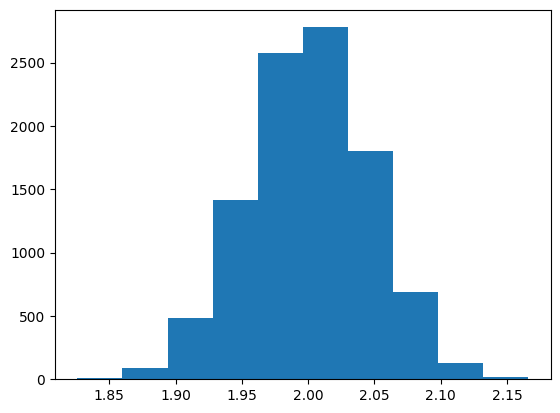

In [89]:
SLR2.run_simulations(10000)
SLR2.plot_sampling_distribution()


In [90]:
SLR2.x

[np.float64(0.0),
 np.float64(1.2),
 np.float64(2.4),
 np.float64(3.5999999999999996),
 np.float64(4.8),
 np.float64(6.0),
 np.float64(7.199999999999999),
 np.float64(8.4),
 np.float64(9.6),
 np.float64(10.799999999999999),
 np.float64(12.0),
 np.float64(0.0),
 np.float64(1.2),
 np.float64(2.4),
 np.float64(3.5999999999999996),
 np.float64(4.8),
 np.float64(6.0),
 np.float64(7.199999999999999),
 np.float64(8.4),
 np.float64(9.6),
 np.float64(10.799999999999999),
 np.float64(12.0),
 np.float64(0.0),
 np.float64(1.2),
 np.float64(2.4),
 np.float64(3.5999999999999996),
 np.float64(4.8),
 np.float64(6.0),
 np.float64(7.199999999999999),
 np.float64(8.4),
 np.float64(9.6),
 np.float64(10.799999999999999),
 np.float64(12.0)]